# Hexbin plotting for Simulation Experiments

In [1]:
%cd ../..

/home/bhkuser/bhklab/katy/recist-vs-reality


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from damply import dirs
from pathlib import Path

from workflow.scripts.utils.metadata_ll import add_source_labels

In [4]:
dataset = "CVPR_LesionLocator"

fig_save_path = Path("figures") / dataset
fig_save_path.mkdir(parents=True, exist_ok=True)

In [3]:
# Load in aligned simulation data 
data_folder = 'AI_for_Onc_2026'
# MedSAM2-RECIST = ms2r
ms2r_recist_path = dirs.RESULTS / data_folder / "ms2r_ll_sim_plotting_info.csv"
# nnInteractive = nnint
nnint_recist_path = dirs.RESULTS / data_folder / "nnInt_ll_sim_plotting_info_pts.csv"

ms2r_recist_df = pd.read_csv(ms2r_recist_path) 
nnint_recist_df = pd.read_csv(nnint_recist_path) 

In [4]:
# Get the stem of the parent directory for each image in the GT_t1_mask_path column
def get_sample_id(path):
    return Path(path).parent.stem

ms2r_recist_df['sample_id'] = ms2r_recist_df['GT_t1_mask_path'].apply(get_sample_id)
nnint_recist_df['sample_id'] = nnint_recist_df['GT_t1_mask_path'].apply(get_sample_id)

In [5]:
# Load in name mapping for the LesionLocator data to the included datasets
name_mapping_path = dirs.RAWDATA / "CVPR_LesionLocator/images/naming.csv"
name_mapping_df = pd.read_csv(name_mapping_path)

ms2r_recist_lbl_df = add_source_labels(ms2r_recist_df, name_mapping_df)
nnint_recist_lbl_df = add_source_labels(nnint_recist_df, name_mapping_df)

In [11]:
nnint_recist_lbl_df[nnint_recist_lbl_df['RECIST_flip'] == True]['GT_RECIST_cat'].value_counts()

GT_RECIST_cat
SD    687
PR    322
PD    301
Name: count, dtype: int64

In [12]:
nnint_recist_lbl_df[nnint_recist_lbl_df['RECIST_flip'] == True]['PRED_RECIST_cat'].value_counts()

PRED_RECIST_cat
PD    552
SD    455
PR    302
CR      1
Name: count, dtype: int64

# 3D DICE

Have to make count hexbin figure first to get the number of values in each bin. The array from this plot is then used to set the alpha in the flip plot below.

## Count Plot

Text(0.5, 0.98, '3D DICE Score vs. Number of Samples in Bin')

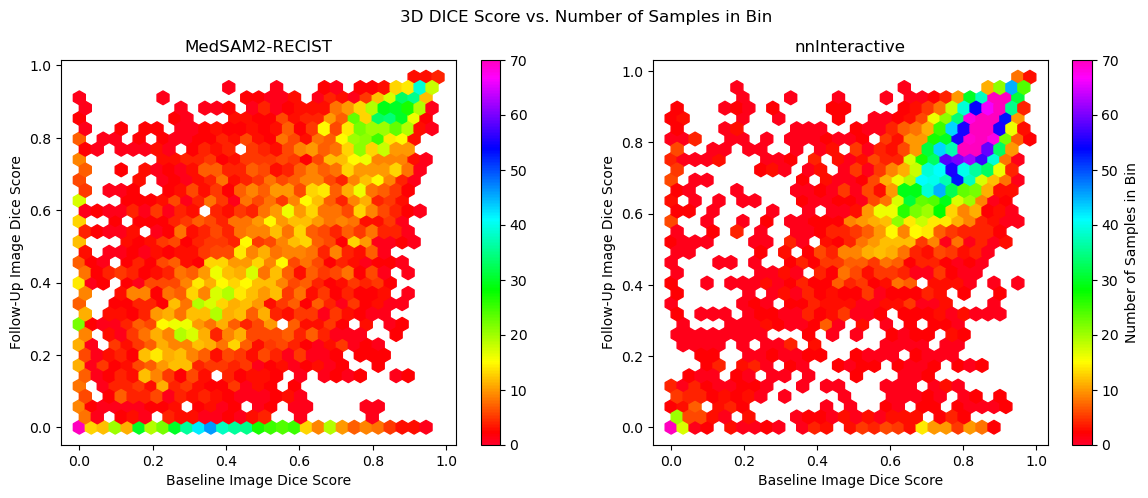

In [20]:
count_fig, count_axes = plt.subplots(figsize = (14,5), nrows = 1, ncols = 2)

count_gridsize = 30
count_cmap = 'gist_rainbow'
count_vmin = 0
count_vmax = 70

# For MedSAM2-RECIST 
ms2r_count = count_axes[0].hexbin(ms2r_recist_df['t1_DICE'], ms2r_recist_df['t2_DICE'],
                               gridsize = count_gridsize,
                               cmap = count_cmap,
                               mincnt = 1,
                               vmin = count_vmin,
                               vmax = count_vmax,
                               )
count_axes[0].set_title("MedSAM2-RECIST")
count_axes[0].set_xlabel("Baseline Image Dice Score") 
count_axes[0].set_ylabel("Follow-Up Image Dice Score")
cb = count_fig.colorbar(ms2r_count, ax = count_axes[0])

# For nnInteractive
nnint_count = count_axes[1].hexbin(nnint_recist_df['t1_DICE'], nnint_recist_df['t2_DICE'],
                                gridsize = count_gridsize,
                                cmap = count_cmap,
                                mincnt = 1,
                                vmin = count_vmin,
                                vmax = count_vmax,
                            )
count_axes[1].set_title("nnInteractive")
count_axes[1].set_xlabel("Baseline Image Dice Score") 
count_axes[1].set_ylabel("Follow-Up Image Dice Score")
cb = count_fig.colorbar(nnint_count, ax = count_axes[1])

cb.set_label("Number of Samples in Bin") 

count_fig.suptitle("3D DICE Score vs. Number of Samples in Bin")

## Flip Plot

Text(0.5, 0.98, '3D DICE Score vs. RECIST Flip Proportion')

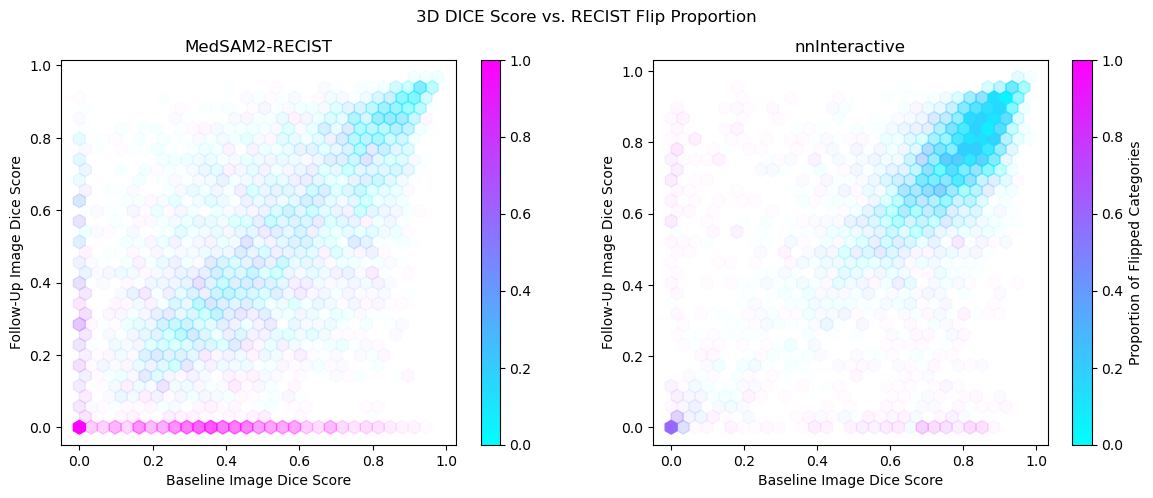

In [21]:
alpha_flip_fig, alpha_flip_axes = plt.subplots(figsize = (14,5), nrows = 1, ncols = 2)
# For MedSAM2-RECIST 
ms2r_hb = alpha_flip_axes[0].hexbin(ms2r_recist_df['t1_DICE'], ms2r_recist_df['t2_DICE'], C=ms2r_recist_df['RECIST_flip'], 
                         reduce_C_function=np.mean, gridsize = 30, cmap = 'cool')

alpha_flip_axes[0].figure.canvas.draw()

fcolors = ms2r_hb.get_facecolors()
scaled_ms2r_count = np.minimum(ms2r_count.get_array() / count_vmax, 1)
fcolors[:, 3] = scaled_ms2r_count
ms2r_hb.set(array=None, facecolor=fcolors)

alpha_flip_axes[0].set_title("MedSAM2-RECIST")
alpha_flip_axes[0].set_xlabel("Baseline Image Dice Score") 
alpha_flip_axes[0].set_ylabel("Follow-Up Image Dice Score")
cb = alpha_flip_fig.colorbar(ms2r_hb, ax = alpha_flip_axes[0])

# For nnInteractive
nnint_hb = alpha_flip_axes[1].hexbin(nnint_recist_df['t1_DICE'], nnint_recist_df['t2_DICE'], C=nnint_recist_df['RECIST_flip'], 
                         reduce_C_function=np.mean, gridsize=30, cmap='cool')

alpha_flip_axes[1].figure.canvas.draw()

fcolors = nnint_hb.get_facecolors()
scaled_nnint_count = np.minimum(nnint_count.get_array() / count_vmax, 1)
fcolors[:, 3] = scaled_nnint_count
nnint_hb.set(array=None, facecolor=fcolors)

alpha_flip_axes[1].set_title("nnInteractive")
alpha_flip_axes[1].set_xlabel("Baseline Image Dice Score") 
alpha_flip_axes[1].set_ylabel("Follow-Up Image Dice Score")
cb = alpha_flip_fig.colorbar(nnint_hb, ax = alpha_flip_axes[1])
cb.set_label("Proportion of Flipped Categories") 

alpha_flip_fig.suptitle("3D DICE Score vs. RECIST Flip Proportion")

KeyError: 'vol_RECIST_flip'

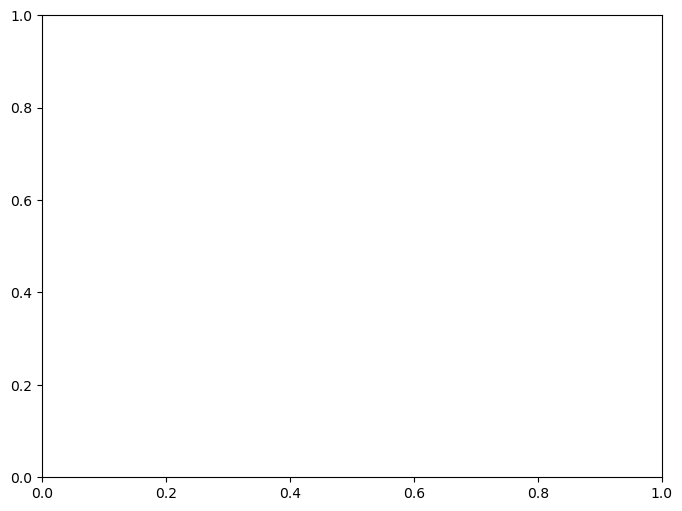

In [11]:
# nnInteractive flip for volume RECIST 
alpha_flip_fig, alpha_flip_axes = plt.subplots(figsize = (8,6), 
                                            #    nrows = 1, ncols = 1
                                               )
# For MedSAM2-RECIST 
# ms2r_hb = alpha_flip_axes[0].hexbin(ms2r_recist_df['t1_DICE'], ms2r_recist_df['t2_DICE'], C=ms2r_recist_df['RECIST_flip'], 
#                          reduce_C_function=np.mean, gridsize = 30, cmap = 'cool')

# alpha_flip_axes[0].figure.canvas.draw()

# fcolors = ms2r_hb.get_facecolors()
# scaled_ms2r_count = np.minimum(ms2r_count.get_array() / count_vmax, 1)
# fcolors[:, 3] = scaled_ms2r_count
# ms2r_hb.set(array=None, facecolor=fcolors)

# alpha_flip_axes[0].set_title("MedSAM2-RECIST")
# alpha_flip_axes[0].set_xlabel("Baseline Image Dice Score") 
# alpha_flip_axes[0].set_ylabel("Follow-Up Image Dice Score")
# cb = alpha_flip_fig.colorbar(ms2r_hb, ax = alpha_flip_axes[0])

# For nnInteractive
nnint_hb = alpha_flip_axes.hexbin(nnint_recist_df['t1_DICE'], nnint_recist_df['t2_DICE'], C=nnint_recist_df['vol_RECIST_flip'], 
                         reduce_C_function=np.mean, gridsize=30, cmap='cool')

alpha_flip_axes.figure.canvas.draw()

fcolors = nnint_hb.get_facecolors()
scaled_nnint_count = np.minimum(nnint_count.get_array() / count_vmax, 1)
fcolors[:, 3] = scaled_nnint_count
nnint_hb.set(array=None, facecolor=fcolors)

alpha_flip_axes.set_title("nnInteractive")
alpha_flip_axes.set_xlabel("Baseline Image Dice Score") 
alpha_flip_axes.set_ylabel("Follow-Up Image Dice Score")
cb = alpha_flip_fig.colorbar(nnint_hb, ax = alpha_flip_axes)
cb.set_label("Proportion of Flipped Categories") 

alpha_flip_fig.suptitle("3D DICE Score vs. Volumetric RECIST Flip Proportion")

# 2D DICE

## Count Plot

Text(0.5, 0.98, '2D DICE Score vs. Number of Samples in Bin')

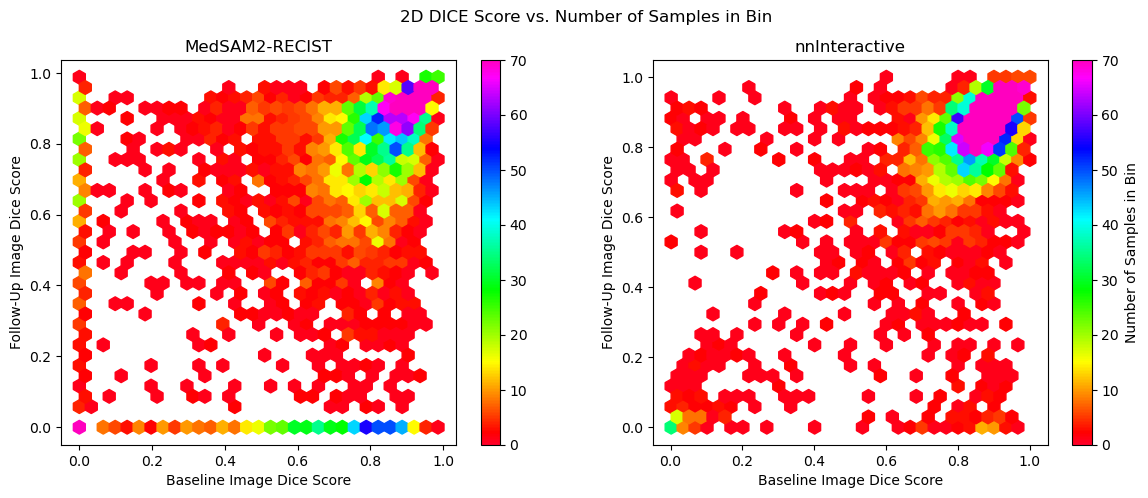

In [34]:
count_2d_fig, count_2d_axes = plt.subplots(figsize = (14,5), nrows = 1, ncols = 2)

count_2d_gridsize = 30
count_2d_cmap = 'gist_rainbow'
count_2d_vmin = 0
count_2d_vmax = 70

# For MedSAM2-RECIST 
ms2r_count = count_2d_axes[0].hexbin(ms2r_recist_df['t1_2D_DICE'], ms2r_recist_df['t2_2D_DICE'],
                               gridsize = count_2d_gridsize,
                               cmap = count_2d_cmap,
                               mincnt = 1,
                               vmin = count_2d_vmin,
                               vmax = count_2d_vmax,
                               )
count_2d_axes[0].set_title("MedSAM2-RECIST")
count_2d_axes[0].set_xlabel("Baseline Image Dice Score") 
count_2d_axes[0].set_ylabel("Follow-Up Image Dice Score")
cb = count_2d_fig.colorbar(ms2r_count, ax = count_2d_axes[0])

# For nnInteractive
nnint_count = count_2d_axes[1].hexbin(nnint_recist_df['t1_2D_DICE'], nnint_recist_df['t2_2D_DICE'],
                                gridsize = count_2d_gridsize,
                                cmap = count_2d_cmap,
                                mincnt = 1,
                                vmin = count_2d_vmin,
                                vmax = count_2d_vmax,
                            )
count_2d_axes[1].set_title("nnInteractive")
count_2d_axes[1].set_xlabel("Baseline Image Dice Score") 
count_2d_axes[1].set_ylabel("Follow-Up Image Dice Score")
cb = count_2d_fig.colorbar(nnint_count, ax = count_2d_axes[1])

cb.set_label("Number of Samples in Bin") 

count_2d_fig.suptitle("2D DICE Score vs. Number of Samples in Bin")

Text(0.5, 0.98, '2D DICE Score vs. RECIST Flip Proportion \n (alpha max = 70)')

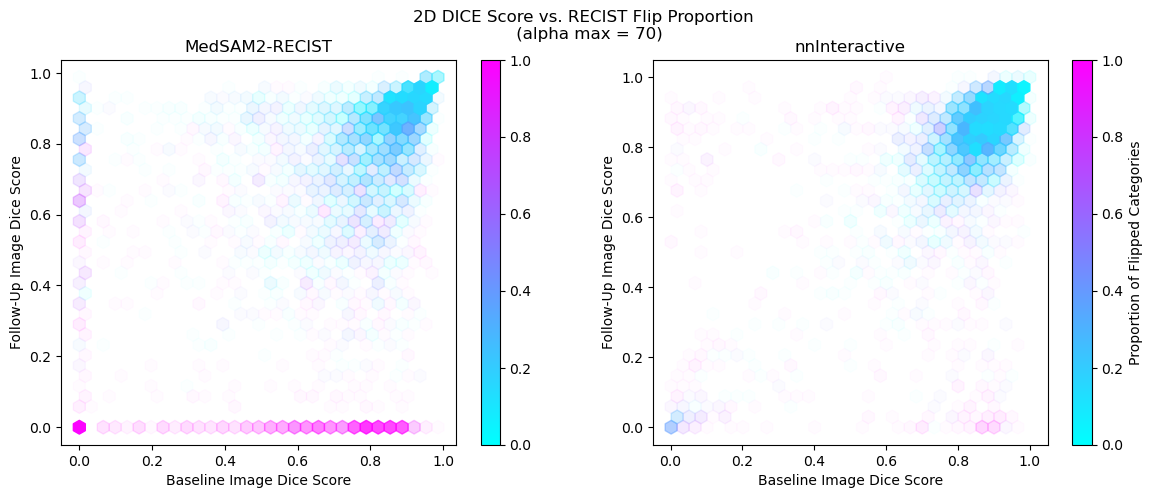

In [ ]:
alpha_2d_flip_fig, alpha_2d_flip_axes = plt.subplots(figsize = (14,5),
                                                     nrows = 1, ncols = 2)
# For MedSAM2-RECIST 
ms2r_hb = alpha_2d_flip_axes[0].hexbin(ms2r_recist_df['t1_2D_DICE'], ms2r_recist_df['t2_2D_DICE'], C=ms2r_recist_df['RECIST_flip'], 
                         reduce_C_function=np.mean, gridsize = 30, cmap = 'cool')

alpha_2d_flip_axes[0].figure.canvas.draw()

fcolors = ms2r_hb.get_facecolors()
scaled_2d_ms2r_count = np.minimum(ms2r_count.get_array() / count_2d_vmax, 1)
fcolors[:, 3] = scaled_2d_ms2r_count
ms2r_hb.set(array=None, facecolor=fcolors)

alpha_2d_flip_axes[0].set_title("MedSAM2-RECIST")
alpha_2d_flip_axes[0].set_xlabel("Baseline Image Dice Score") 
alpha_2d_flip_axes[0].set_ylabel("Follow-Up Image Dice Score")
cb = alpha_2d_flip_fig.colorbar(ms2r_hb, ax = alpha_2d_flip_axes[0])

# For nnInteractive
nnint_hb = alpha_2d_flip_axes[1].hexbin(nnint_recist_df['t1_2D_DICE'], nnint_recist_df['t2_2D_DICE'], C=nnint_recist_df['vol_RECIST_flip'], 
                         reduce_C_function=np.mean, gridsize=30, cmap='cool')

alpha_2d_flip_axes[1].figure.canvas.draw()

fcolors = nnint_hb.get_facecolors()
scaled_nnint_count = np.minimum(nnint_count.get_array() / count_vmax, 1)
fcolors[:, 3] = scaled_nnint_count
nnint_hb.set(array=None, facecolor=fcolors)

alpha_2d_flip_axes[1].set_title("nnInteractive")
alpha_2d_flip_axes[1].set_xlabel("Baseline Image Dice Score") 
alpha_2d_flip_axes[1].set_ylabel("Follow-Up Image Dice Score")
cb = alpha_2d_flip_fig.colorbar(nnint_hb, ax = alpha_2d_flip_axes[1])
cb.set_label("Proportion of Flipped Categories") 

alpha_2d_flip_fig.suptitle(f"2D DICE Score vs. RECIST Flip Proportion \n (alpha max = {count_2d_vmax})")


Text(0.5, 0.98, '2D DICE Score vs. Volumetric RECIST Flip Proportion')

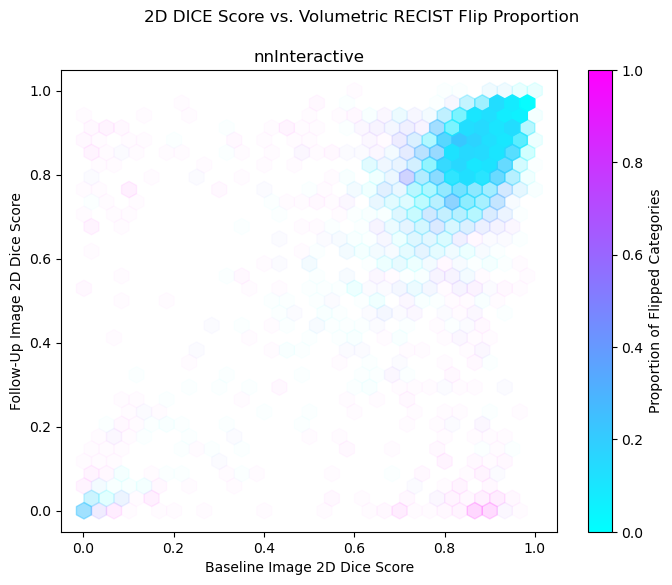

In [38]:
# nnInteractive flip for volume RECIST 
alpha_flip_fig, alpha_flip_axes = plt.subplots(figsize = (8,6), 
                                            #    nrows = 1, ncols = 1
                                               )
# For MedSAM2-RECIST 
# ms2r_hb = alpha_flip_axes[0].hexbin(ms2r_recist_df['t1_DICE'], ms2r_recist_df['t2_DICE'], C=ms2r_recist_df['RECIST_flip'], 
#                          reduce_C_function=np.mean, gridsize = 30, cmap = 'cool')

# alpha_flip_axes[0].figure.canvas.draw()

# fcolors = ms2r_hb.get_facecolors()
# scaled_ms2r_count = np.minimum(ms2r_count.get_array() / count_vmax, 1)
# fcolors[:, 3] = scaled_ms2r_count
# ms2r_hb.set(array=None, facecolor=fcolors)

# alpha_flip_axes[0].set_title("MedSAM2-RECIST")
# alpha_flip_axes[0].set_xlabel("Baseline Image Dice Score") 
# alpha_flip_axes[0].set_ylabel("Follow-Up Image Dice Score")
# cb = alpha_flip_fig.colorbar(ms2r_hb, ax = alpha_flip_axes[0])

# For nnInteractive
nnint_hb = alpha_flip_axes.hexbin(nnint_recist_df['t1_2D_DICE'], nnint_recist_df['t2_2D_DICE'], C=nnint_recist_df['vol_RECIST_flip'], 
                         reduce_C_function=np.mean, gridsize=30, cmap='cool')

alpha_flip_axes.figure.canvas.draw()

fcolors = nnint_hb.get_facecolors()
scaled_nnint_count = np.minimum(nnint_count.get_array() / count_vmax, 1)
fcolors[:, 3] = scaled_nnint_count
nnint_hb.set(array=None, facecolor=fcolors)

alpha_flip_axes.set_title("nnInteractive")
alpha_flip_axes.set_xlabel("Baseline Image 2D Dice Score") 
alpha_flip_axes.set_ylabel("Follow-Up Image 2D Dice Score")
cb = alpha_flip_fig.colorbar(nnint_hb, ax = alpha_flip_axes)
cb.set_label("Proportion of Flipped Categories") 

alpha_flip_fig.suptitle("2D DICE Score vs. Volumetric RECIST Flip Proportion")

In [ ]:

alpha_2d_flip_fig.savefig()

# Flippin scatterplots

In [6]:
lesion_recist_results = nnint_recist_lbl_df
model_title = "nnInteractive"

In [19]:
def plot_recist_flip_scatter(lesion_recist_results, y_axis_data, cbar_data, model_title, pr_line = True, pd_line = True):
    fig, axes = plt.subplots(figsize=(17, 5), ncols=2, nrows=1, width_ratios=[0.8,1], tight_layout=True)

    tp1 = axes[0]
    tp2 = axes[1]

    tp1.scatter(lesion_recist_results['source_id'], lesion_recist_results[y_axis_data], c=lesion_recist_results[cbar_data], cmap='jet', alpha=0.7)
    tp1.set_xticks([])
    tp1.set_title("Timepoint 1")
    tp1.set_xlabel("Individual Lesions")
    tp1.set_ylabel("Change in Diameter (%)")

    tp2.scatter(lesion_recist_results['source_id'], lesion_recist_results[y_axis_data], c=lesion_recist_results[cbar_data], cmap='jet', alpha=0.7)
    tp2.set_xticks([])
    tp2.set_title("Timepoint 2")
    tp2.set_xlabel("Individual Lesions")
    tp2.set_ylabel("Change in Diameter (%)")

    if pd_line:
        pd_color = "#0008FF"
        tp1.axhline(y = 20, linestyle='--', color=pd_color, label='RECIST PD Threshold')
        tp2.axhline(y = 20, linestyle='--', color=pd_color)
    if pr_line:
        pr_color = "#066F00"
        tp1.axhline(y = -30, linestyle=':', linewidth=2.5, color=pr_color, label='RECIST PR Threshold')
        tp2.axhline(y = -30, linestyle=':', linewidth=2.5, color=pr_color)

    cb = fig.colorbar(tp2.collections[0], ticks=np.arange(0, 1.1, 0.1), label=cbar_data)

    fig.suptitle(f"{model_title} -  RECIST Flipped Lesions' {y_axis_data} Colored by {cbar_data}", fontsize=16)
    fig.legend(loc='lower center', ncols = 2)

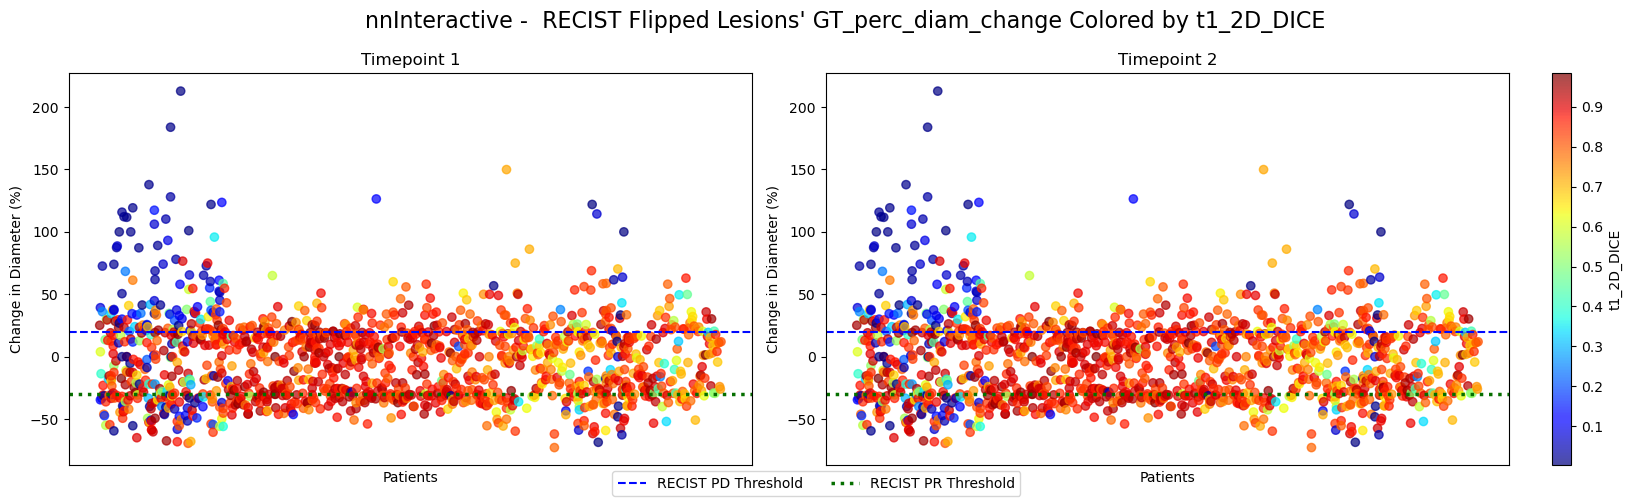

In [15]:
flipped_target_lesions = lesion_recist_results[lesion_recist_results['RECIST_flip'] == True]

plot_recist_flip_scatter(flipped_target_lesions, 'GT_perc_diam_change', 't1_2D_DICE', model_title)

In [7]:
pr_boundary_range = (-40, -20)
pr_boundary_lesions_2D = lesion_recist_results[(lesion_recist_results['GT_perc_diam_change'] >= pr_boundary_range[0]) & 
                                               (lesion_recist_results['GT_perc_diam_change'] <= pr_boundary_range[1])]

pd_boundary_range = (10, 30)
pd_boundary_lesions_2D = lesion_recist_results[(lesion_recist_results['GT_perc_diam_change'] >= pd_boundary_range[0]) & 
                                               (lesion_recist_results['GT_perc_diam_change'] <= pd_boundary_range[1])]

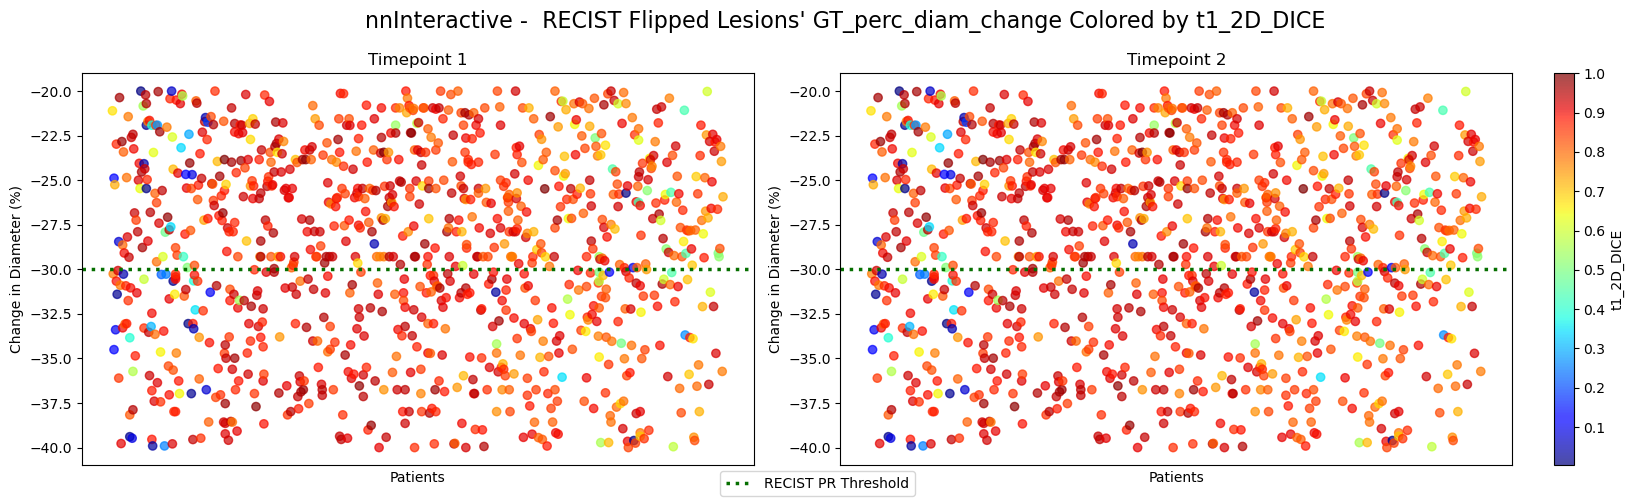

In [18]:
plot_recist_flip_scatter(pr_boundary_lesions_2D, 'GT_perc_diam_change', 't1_2D_DICE', model_title, pd_line=False)

In [ ]:
plot_recist_flip_scatter(pr_boundary_lesions_2D, 'GT_perc_diam_change', 't1_2D_DICE', model_title, pd_line=False)

,GT_t1_mask_path,GT_t2_mask_path,GT_t1_max_ax_diam,GT_t2_max_ax_diam,GT_t1_vox_vol,GT_t2_vox_vol,GT_perc_diam_change,GT_perc_vol_change,GT_RECIST_cat,GT_vol_RECIST_cat,...,t2_2D_DICE,t1_HD95,t2_HD95,t1_surface_distance,t2_surface_distance,RECIST_flip,vol_RECIST_flip,sample_id,source_id,source_dataset
2,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,22.152182,27.729809,2860.082405,4968.132879,25.178676,73.705935,PD,PD,...,0.938032,6.460171,1.597656,1.513036,0.565855,True,True,LesionLocator_0002,KiTS23_case_00001,KiTS
3,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,20.689309,23.486328,3961.866489,4129.555202,13.519152,4.232569,SD,SD,...,0.884956,6.579733,6.576172,0.707795,0.664469,False,False,LesionLocator_0003,KiTS23_case_00002,KiTS
4,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,46.262701,51.154926,37011.546692,52394.779686,10.574880,41.563335,SD,SD,...,0.965103,1.878906,1.662872,0.540459,0.501411,False,False,LesionLocator_0003,KiTS23_case_00002,KiTS
6,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,28.022315,34.314855,11372.588196,18884.058289,22.455462,66.048906,PD,SD,...,0.930730,3.557968,1.710938,0.690602,0.528615,False,True,LesionLocator_0004,KiTS23_case_00003,KiTS
10,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,28.242160,31.645399,11295.021057,15801.461792,12.050206,39.897586,SD,SD,...,0.394315,163.127655,174.714005,64.404495,65.973450,False,True,LesionLocator_0007,KiTS23_case_00006,KiTS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5468,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,38.002343,42.181407,5713.882304,3988.335377,10.996859,-30.199203,SD,SD,...,0.857579,6.387021,9.542170,0.253963,0.412455,False,False,LesionLocator_2582,NSCLC-Radiogenomics_R01-079,NSCLC-\nRadiogenomics
5470,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,17.684347,19.682395,1162.523273,2333.141117,11.298394,100.696293,SD,PD,...,0.892794,4.364178,1.756754,1.048060,0.557205,True,False,LesionLocator_2584,NSCLC-Radiogenomics_R01-081,NSCLC-\nRadiogenomics
5479,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,15.944641,19.503065,1138.175171,2580.939316,22.317368,126.761168,PD,PD,...,0.861996,3.382977,2.216135,0.485196,0.466723,False,False,LesionLocator_2593,NSCLC-Radiogenomics_R01-091,NSCLC-\nRadiogenomics
5482,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,27.674251,30.991673,3526.354063,10427.015622,11.987394,195.688279,SD,PD,...,0.931801,3.109928,1.898438,0.700811,0.629051,True,False,LesionLocator_2596,NSCLC-Radiogenomics_R01-094,NSCLC-\nRadiogenomics
